In [ ]:
# ==========================================================
# Consumer Grievance Analytics System
# Author: Aditya Babar
# Purpose: Load and inspect the raw consumer grievances dataset
# ==========================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

# Load Dataset
df = pd.read_csv("../data/consumer_grievances.csv")

# ----------------------------------------------------------
# Basic Dataset Information
# ----------------------------------------------------------

print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\n" + "=" * 60)
print("COLUMN NAMES")
print("=" * 60)

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("FIRST 5 RECORDS")
print("=" * 60)
print(df.head())

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(df.isnull().sum())

print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
print(df.duplicated().sum())

DATASET SHAPE
Rows    : 1000
Columns : 8

COLUMN NAMES
1. Complaint ID
2. Customer ID
3. Product/Service
4. Complaint Category
5. Date Filed
6. Date Resolved
7. Status
8. Resolution Time (Days)

DATA TYPES
Complaint ID                int64
Customer ID                 int64
Product/Service            object
Complaint Category         object
Date Filed                 object
Date Resolved              object
Status                     object
Resolution Time (Days)    float64
dtype: object

FIRST 5 RECORDS
   Complaint ID  Customer ID  Product/Service Complaint Category  Date Filed  \
0        820407        28631   Insurance Plan           Delivery  2024-05-24   
1        262537        23083    Digital Scale    Product Quality  2024-06-30   
2        459273        52729    Digital Scale            Service  2024-05-10   
3        271580        63115    Personal Safe           Delivery  2023-10-26   
4        282178        17532  Fitness Tracker    Product Quality  2024-07-18   

  Date Res

# Data Validation

In this section, we validate the quality of the dataset before cleaning it. We check:

- Missing values
- Duplicate records
- Unique values in categorical columns
- Statistical summary of numerical columns

This helps identify potential issues before preprocessing.

In [5]:
# ==========================================================
# Author: Aditya Babar
# Data Validation
# ==========================================================

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(df.isnull().sum())

print("\n" + "=" * 60)
print("DUPLICATE RECORDS")
print("=" * 60)
print(df.duplicated().sum())

print("\n" + "=" * 60)
print("UNIQUE VALUES IN CATEGORICAL COLUMNS")
print("=" * 60)

categorical_columns = [
    "Product/Service",
    "Complaint Category",
    "Status"
]

for column in categorical_columns:
    print(f"\n📌 {column}")
    print("-" * 40)
    print(df[column].value_counts())

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
print(df.describe())

MISSING VALUES
Complaint ID                0
Customer ID                 0
Product/Service             0
Complaint Category          0
Date Filed                  0
Date Resolved             187
Status                      0
Resolution Time (Days)    187
dtype: int64

DUPLICATE RECORDS
0

UNIQUE VALUES IN CATEGORICAL COLUMNS

📌 Product/Service
----------------------------------------
Product/Service
Fitness Tracker             118
Digital Scale               106
Home Security System        106
Personal Safe               102
Insurance Plan              100
Drone Delivery Service       97
Mobile Banking App           97
Cloud Storage                93
Weight Loss Program          93
Customer Support Service     88
Name: count, dtype: int64

📌 Complaint Category
----------------------------------------
Complaint Category
Service              221
Technical Support    209
Product Quality      196
Delivery             190
Billing              184
Name: count, dtype: int64

📌 Status
--------

# Data Cleaning

In this step, we clean the dataset to improve data quality.

The cleaning process includes:

- Converting date columns to datetime format
- Checking for missing values
- Removing duplicate records (if any)
- Verifying the cleaned dataset before further analysis

In [6]:
# ==========================================================
# Author: Aditya Babar
# Data Cleaning
# ==========================================================

# Create a copy of the original dataset
cleaned_df = df.copy()

# Convert date columns to datetime format
cleaned_df["Date Filed"] = pd.to_datetime(cleaned_df["Date Filed"])
cleaned_df["Date Resolved"] = pd.to_datetime(cleaned_df["Date Resolved"])

# Check missing values before cleaning
print("=" * 60)
print("MISSING VALUES BEFORE CLEANING")
print("=" * 60)
print(cleaned_df.isnull().sum())

# Remove duplicate records
cleaned_df.drop_duplicates(inplace=True)

# Check missing values after removing duplicates
print("\n" + "=" * 60)
print("MISSING VALUES AFTER CLEANING")
print("=" * 60)
print(cleaned_df.isnull().sum())

# Display dataset information
print("\n" + "=" * 60)
print("CLEANED DATASET SHAPE")
print("=" * 60)
print(cleaned_df.shape)

print("\nDate columns converted successfully.")

MISSING VALUES BEFORE CLEANING
Complaint ID                0
Customer ID                 0
Product/Service             0
Complaint Category          0
Date Filed                  0
Date Resolved             187
Status                      0
Resolution Time (Days)    187
dtype: int64

MISSING VALUES AFTER CLEANING
Complaint ID                0
Customer ID                 0
Product/Service             0
Complaint Category          0
Date Filed                  0
Date Resolved             187
Status                      0
Resolution Time (Days)    187
dtype: int64

CLEANED DATASET SHAPE
(1000, 8)

Date columns converted successfully.


# Feature Engineering

Feature engineering involves creating new columns from existing data to improve analysis.

In this section, we create:

- Month-Year column for monthly trend analysis
- Resolution Flag to identify resolved complaints
- Timely Resolution Flag to identify complaints resolved within 10 days

These new features will be used in data visualization and the Power BI dashboard.

In [7]:
# ==========================================================
# Author: Aditya Babar
# Feature Engineering
# ==========================================================

# Create Month-Year column for trend analysis
cleaned_df["Month_Year"] = cleaned_df["Date Filed"].dt.to_period("M").astype(str)

# Create Resolution Flag
cleaned_df["Resolution_Flag"] = cleaned_df["Status"].apply(
    lambda x: 1 if x == "Resolved" else 0
)

# Create Timely Resolution Flag
# A complaint is considered timely if resolved within 10 days
cleaned_df["Is_Timely"] = cleaned_df["Resolution Time (Days)"].apply(
    lambda x: 1 if pd.notna(x) and x <= 10 else 0
)

print("=" * 60)
print("NEW FEATURES CREATED")
print("=" * 60)

print(cleaned_df[[
    "Date Filed",
    "Month_Year",
    "Status",
    "Resolution Time (Days)",
    "Resolution_Flag",
    "Is_Timely"
]].head())

print("\nDataset Shape:")
print(cleaned_df.shape)

NEW FEATURES CREATED
  Date Filed Month_Year      Status  Resolution Time (Days)  Resolution_Flag  \
0 2024-05-24    2024-05    Resolved                    18.0                1   
1 2024-06-30    2024-06    Resolved                    28.0                1   
2 2024-05-10    2024-05    Resolved                    10.0                1   
3 2023-10-26    2023-10  Unresolved                     NaN                0   
4 2024-07-18    2024-07    Resolved                    29.0                1   

   Is_Timely  
0          0  
1          0  
2          1  
3          0  
4          0  

Dataset Shape:
(1000, 11)


# Complaint Category Analysis

Understanding the distribution of complaint categories helps identify the most common issues reported by consumers.

This visualization highlights the complaint categories with the highest number of grievances.

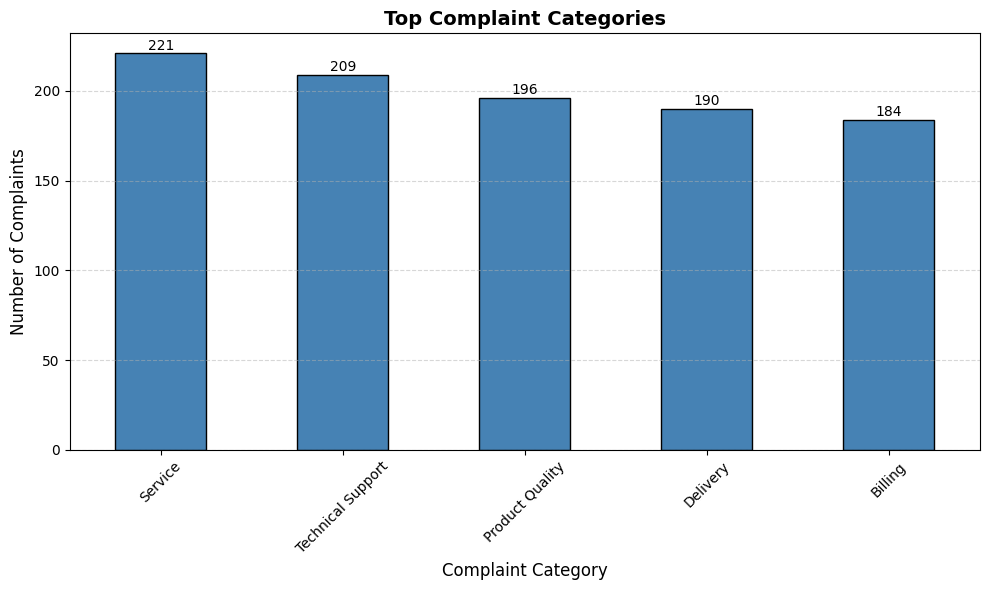

In [8]:
# ==========================================================
# Author: Aditya Babar
# Complaint Category Analysis
# ==========================================================

# Count complaints by category
category_counts = (
    cleaned_df["Complaint Category"]
    .value_counts()
    .sort_values(ascending=False)
)

# Create the figure
plt.figure(figsize=(10, 6))

# Plot bar chart
category_counts.plot(kind="bar", color="steelblue", edgecolor="black")

# Add title and labels
plt.title("Top Complaint Categories", fontsize=14, fontweight="bold")
plt.xlabel("Complaint Category", fontsize=12)
plt.ylabel("Number of Complaints", fontsize=12)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Add value labels on bars
for index, value in enumerate(category_counts):
    plt.text(index, value + 2, str(value), ha="center", fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Monthly Complaint Trend Analysis

Trend analysis helps identify how complaint volumes change over time.

The line chart below shows the monthly number of complaints along with a 3-month rolling average to smooth short-term fluctuations and highlight overall trends.

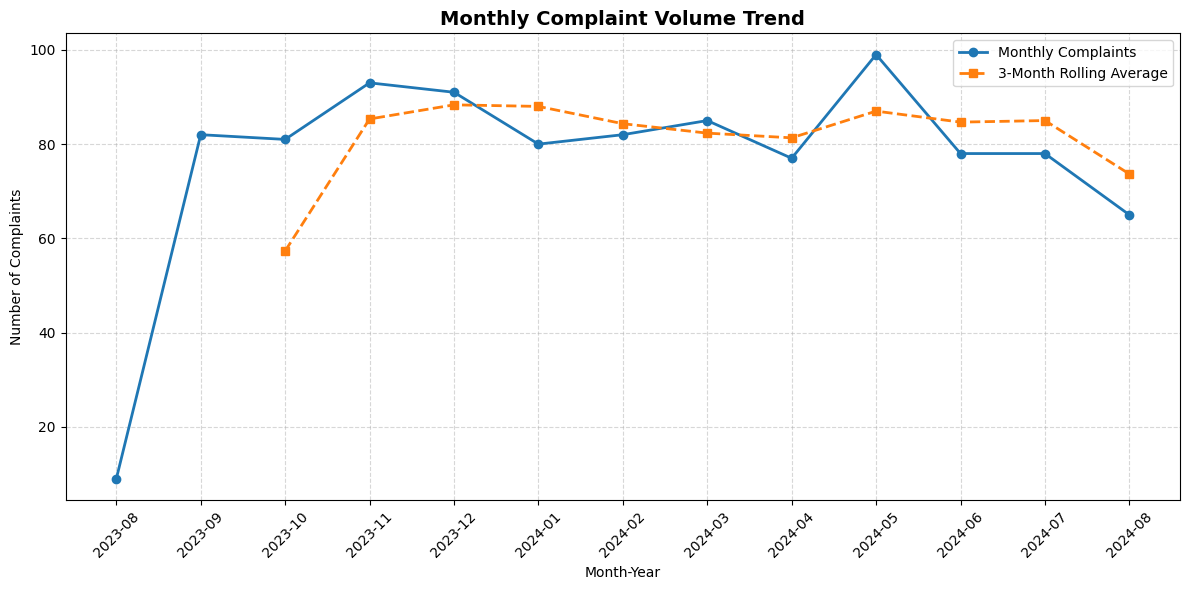

In [9]:
# ==========================================================
# Author: Aditya Babar
# Monthly Complaint Trend Analysis
# ==========================================================

# Count complaints by month
monthly_complaints = (
    cleaned_df
    .groupby("Month_Year")
    .size()
    .reset_index(name="Complaint Count")
)

# Calculate 3-month rolling average
monthly_complaints["Rolling Average"] = (
    monthly_complaints["Complaint Count"]
    .rolling(window=3)
    .mean()
)

# Plot the trend
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_complaints["Month_Year"],
    monthly_complaints["Complaint Count"],
    marker="o",
    linewidth=2,
    label="Monthly Complaints"
)

plt.plot(
    monthly_complaints["Month_Year"],
    monthly_complaints["Rolling Average"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="3-Month Rolling Average"
)

plt.title("Monthly Complaint Volume Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month-Year")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# Resolution Status Distribution

Understanding the proportion of resolved and unresolved complaints helps evaluate the effectiveness of the grievance resolution process.

The chart below shows the distribution of complaint resolution status.

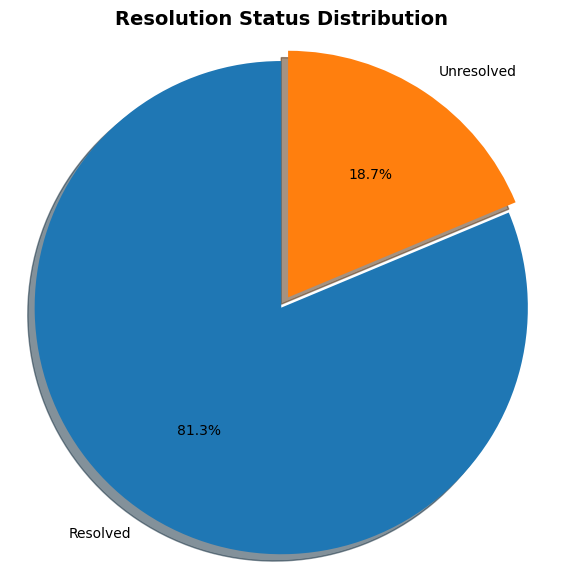

In [10]:
# ==========================================================
# Author: Aditya Babar
# Resolution Status Distribution
# ==========================================================

# Count complaints by resolution status
status_counts = cleaned_df["Status"].value_counts()

# Create the figure
plt.figure(figsize=(7, 7))

# Plot pie chart
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0.05, 0),
    shadow=True
)

# Add title
plt.title("Resolution Status Distribution", fontsize=14, fontweight="bold")

# Keep the pie chart circular
plt.axis("equal")

plt.show()

# Complaint Category vs Resolution Status Heatmap

This heatmap shows the number of complaints for each complaint category, split by resolution status.

It helps identify which categories have the highest number of unresolved complaints and provides a quick visual comparison across complaint types.

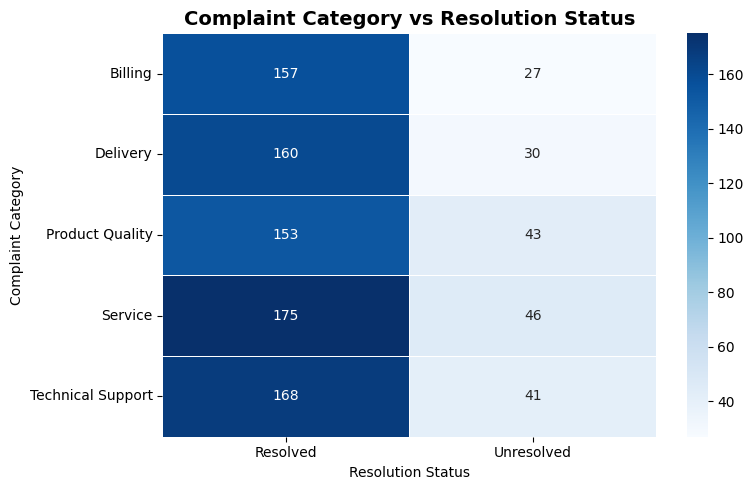

In [11]:
# ==========================================================
# Author: Aditya Babar
# Complaint Category vs Resolution Status Heatmap
# ==========================================================

# Create a pivot table
heatmap_data = pd.crosstab(
    cleaned_df["Complaint Category"],
    cleaned_df["Status"]
)

# Create the figure
plt.figure(figsize=(8, 5))

# Plot heatmap
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

# Add title and labels
plt.title(
    "Complaint Category vs Resolution Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Resolution Status")
plt.ylabel("Complaint Category")

plt.tight_layout()
plt.show()

# Statistical Summary

This section summarizes the key statistics for complaint resolution time.

The metrics below provide insights into the average, median, minimum, maximum, and variability of complaint resolution duration.

In [12]:
# ==========================================================
# Author: Aditya Babar
# Statistical Summary
# ==========================================================

# Statistical summary for resolution time
resolution_stats = cleaned_df["Resolution Time (Days)"].describe()

print("=" * 60)
print("STATISTICAL SUMMARY OF RESOLUTION TIME")
print("=" * 60)

print(f"Mean Resolution Time   : {resolution_stats['mean']:.2f} days")
print(f"Median Resolution Time : {cleaned_df['Resolution Time (Days)'].median():.2f} days")
print(f"Minimum Resolution Time: {resolution_stats['min']:.0f} day(s)")
print(f"Maximum Resolution Time: {resolution_stats['max']:.0f} days")
print(f"Standard Deviation     : {resolution_stats['std']:.2f} days")

STATISTICAL SUMMARY OF RESOLUTION TIME
Mean Resolution Time   : 15.25 days
Median Resolution Time : 15.00 days
Minimum Resolution Time: 1 day(s)
Maximum Resolution Time: 30 days
Standard Deviation     : 8.80 days


# Export Cleaned Dataset

After preprocessing and feature engineering, the cleaned dataset is exported for use in:

- Power BI Dashboard
- Automated PDF Report
- Further data analysis

The cleaned dataset is saved in the `data` folder.

In [13]:
# ==========================================================
# Author: Aditya Babar
# Export Cleaned Dataset
# ==========================================================

# Export cleaned dataset
output_path = "../data/cleaned_consumer_grievances.csv"

cleaned_df.to_csv(output_path, index=False)

print("=" * 60)
print("DATASET EXPORTED SUCCESSFULLY")
print("=" * 60)
print(f"File saved to: {output_path}")

print("\nPreview of exported dataset:")
print(cleaned_df.head())

print("\nFinal Dataset Shape:")
print(cleaned_df.shape)

DATASET EXPORTED SUCCESSFULLY
File saved to: ../data/cleaned_consumer_grievances.csv

Preview of exported dataset:
   Complaint ID  Customer ID  Product/Service Complaint Category Date Filed  \
0        820407        28631   Insurance Plan           Delivery 2024-05-24   
1        262537        23083    Digital Scale    Product Quality 2024-06-30   
2        459273        52729    Digital Scale            Service 2024-05-10   
3        271580        63115    Personal Safe           Delivery 2023-10-26   
4        282178        17532  Fitness Tracker    Product Quality 2024-07-18   

  Date Resolved      Status  Resolution Time (Days) Month_Year  \
0    2024-06-11    Resolved                    18.0    2024-05   
1    2024-07-28    Resolved                    28.0    2024-06   
2    2024-05-20    Resolved                    10.0    2024-05   
3           NaT  Unresolved                     NaN    2023-10   
4    2024-08-16    Resolved                    29.0    2024-07   

   Resolution